In [ ]:
# AUC notebook for Convolutional-FMNIST
# Reads averaged CSV files created by Untitled.ipynb and computes Area Under the Curve

[INFO] Graphs: C:\Users\Student\Desktop\Neural_research\physlab\Convolution\Convolutional\Convolutional-FMNIST\AUC_graph
[INFO] AUC data: C:\Users\Student\Desktop\Neural_research\physlab\Convolution\Convolutional\Convolutional-FMNIST\AUC_data

Processing prune layer: CONV
[WARNING] File not found: C:\Users\Student\Desktop\Neural_research\physlab\Convolution\Convolutional\Convolutional-FMNIST\prune_layers_CONV\p-percentage_1.0\batch_size_64\averaged_runs_p_1.0_bs_64.csv
[SAVED] C:\Users\Student\Desktop\Neural_research\physlab\Convolution\Convolutional\Convolutional-FMNIST\AUC_graph\CONV\CONV_Average_CE_Train_BS_64.png
[SAVED] C:\Users\Student\Desktop\Neural_research\physlab\Convolution\Convolutional\Convolutional-FMNIST\AUC_graph\CONV\CONV_Average_CE_Test_BS_64.png
[WARNING] File not found: C:\Users\Student\Desktop\Neural_research\physlab\Convolution\Convolutional\Convolutional-FMNIST\prune_layers_CONV\p-percentage_1.0\batch_size_1024\averaged_runs_p_1.0_bs_1024.csv
[SAVED] C:\Users\Stu

KeyboardInterrupt: 

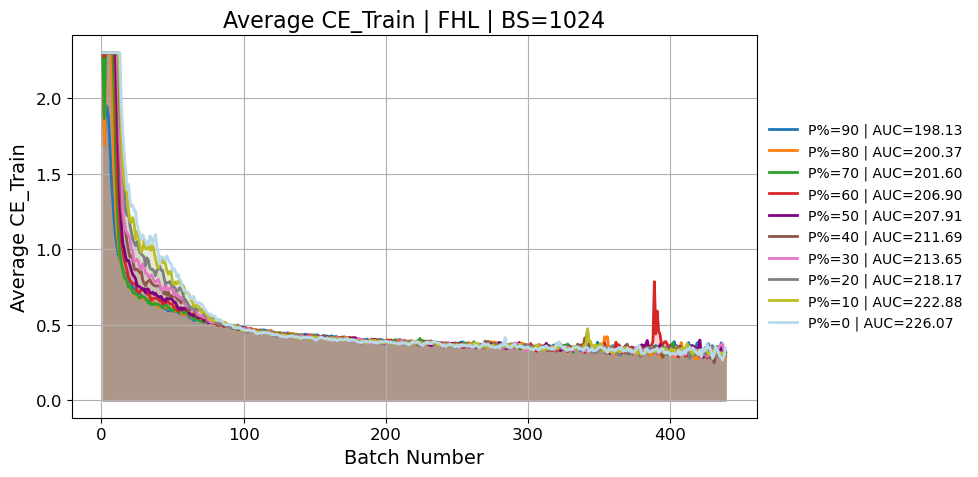

In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================
# CONFIG (Convolutional FMNIST)
# =========================
BASE_DIR_ROOT = r"C:\Users\Student\Desktop\Neural_research\physlab\Convolution\Convolutional\Convolutional-FMNIST"

PRUNE_LAYERS_OPTIONS = ['CONV', 'FHL', 'SHL', 'FHL+SHL', 'ALL']

PRUNE_LAYER_DIR_MAP = {
    "CONV":    "prune_layers_CONV",
    "FHL":     "prune_layers_FHL",
    "SHL":     "prune_layers_SHL",
    "FHL+SHL": "prune_layers_FHL+SHL",
    "ALL":     "prune_layers_ALL"
}

BATCH_DIR_TEMPLATE = "p-percentage_{:.1f}\\batch_size_{}"
BATCH_SIZES = [64, 1024]
PRUNING_PERCENTAGES = [round(x * 0.1, 1) for x in range(0, 11)]

# =========================
# CREATE OUTPUT DIRECTORIES
# =========================
AUC_GRAPH_DIR = os.path.join(BASE_DIR_ROOT, "AUC_graph")
AUC_DATA_DIR  = os.path.join(BASE_DIR_ROOT, "AUC_data")
os.makedirs(AUC_GRAPH_DIR, exist_ok=True)
os.makedirs(AUC_DATA_DIR,  exist_ok=True)
print(f"[INFO] Graphs: {AUC_GRAPH_DIR}")
print(f"[INFO] AUC data: {AUC_DATA_DIR}")

# =========================
# STYLE
# =========================
plt.rcParams.update({
    "font.size":       14,
    "axes.titlesize":  16,
    "axes.labelsize":  14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 10
})

# Maximum CE cap
CE_MAX = np.log(10)  # ≈ 2.3026

# =========================
# DEFINE COLORS (matches SLP/FMNIST)
# =========================
COLOR_LIST = [
    "#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#800080",
    "#8c564b", "#e377c2", "#7f7f7f", "#bcbd22", "#B9D9EB", "#17becf"
]

# =========================
# MAIN LOOP
# =========================
for prune_layer in PRUNE_LAYERS_OPTIONS:

    print(f"\nProcessing prune layer: {prune_layer}")

    base_dir = os.path.join(BASE_DIR_ROOT, PRUNE_LAYER_DIR_MAP[prune_layer])

    layer_graph_dir = os.path.join(AUC_GRAPH_DIR, prune_layer)
    layer_data_dir  = os.path.join(AUC_DATA_DIR,  prune_layer)
    os.makedirs(layer_graph_dir, exist_ok=True)
    os.makedirs(layer_data_dir,  exist_ok=True)

    auc_table = []

    for bs in BATCH_SIZES:

        avg_dfs = {}

        # -------------------------
        # LOAD AVERAGED FILES
        # -------------------------
        for p in PRUNING_PERCENTAGES:
            folder    = os.path.join(base_dir, BATCH_DIR_TEMPLATE.format(p, bs))
            file_path = os.path.join(folder, f"averaged_runs_p_{p}_bs_{bs}.csv")

            if not os.path.isfile(file_path):
                print(f"[WARNING] File not found: {file_path}")
                continue

            df = pd.read_csv(file_path)
            df["Avg_CE_Train"] = np.minimum(df["Avg_CE_Train"], CE_MAX)
            df["Avg_CE_Test"]  = np.minimum(df["Avg_CE_Test"],  CE_MAX)
            avg_dfs[p] = df

        if not avg_dfs:
            print(f"No data found for {prune_layer}, batch size {bs}")
            continue

        # -------------------------
        # Find lowest max Batch_Number (excluding 100%)
        # -------------------------
        non100_dfs = {p: df for p, df in avg_dfs.items() if p != 1.0}
        if non100_dfs:
            lowest_max_batch = min(df["Batch_Number"].max() for df in non100_dfs.values())
        else:
            lowest_max_batch = min(df["Batch_Number"].max() for df in avg_dfs.values())

        # -------------------------
        # PLOT FUNCTION
        # -------------------------
        def plot_ce(avg_dfs, bs, ce_column, title):

            plt.figure(figsize=(10, 5))
            plt.title(f"{title} | {prune_layer} | BS={bs}")
            plt.xlabel("Batch Number")
            plt.ylabel(title)

            for i, p in enumerate(sorted(avg_dfs.keys(), reverse=True)):
                df    = avg_dfs[p]
                color = COLOR_LIST[i % len(COLOR_LIST)]

                if p == 1.0:
                    ce_value = min(df[ce_column].iloc[-1], CE_MAX)
                    x_clean  = np.array([0, lowest_max_batch])
                    y_clean  = np.array([ce_value, ce_value])
                    auc      = ce_value * lowest_max_batch

                    plt.plot(x_clean, y_clean, color=color, linewidth=2.5,
                             label=f"P%={int(p*100)} | AUC={auc:.2f}")

                else:
                    df_trunc = df[df["Batch_Number"] <= lowest_max_batch]
                    x = df_trunc["Batch_Number"].to_numpy()
                    y = np.minimum(df_trunc[ce_column].to_numpy(), CE_MAX)

                    mask    = np.isfinite(x) & np.isfinite(y)
                    x_clean = x[mask]
                    y_clean = y[mask]

                    if len(x_clean) == 0:
                        print(f"[WARNING] All NaN for P%={p}")
                        continue

                    auc = np.trapezoid(y_clean, x_clean)

                    plt.plot(x_clean, y_clean, color=color, linewidth=2.0,
                             label=f"P%={int(p*100)} | AUC={auc:.2f}")
                    plt.fill_between(x_clean, y_clean, alpha=0.2, color=color)

                auc_table.append({
                    "Batch_Size":         bs,
                    "Pruning_Percentage": p,
                    "CE_Type":            ce_column,
                    "AUC":                auc
                })

            plt.grid(True)
            plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), frameon=False)
            plt.tight_layout()

            save_name = f"{prune_layer}_{title.replace(' ', '_')}_BS_{bs}.png"
            save_path = os.path.join(layer_graph_dir, save_name)
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
            plt.close()
            print(f"[SAVED] {save_path}")

        # -------------------------
        # Plot CE_Train & CE_Test
        # -------------------------
        plot_ce(avg_dfs, bs, "Avg_CE_Train", "Average CE_Train")
        plot_ce(avg_dfs, bs, "Avg_CE_Test",  "Average CE_Test")

    # -------------------------
    # SAVE AUC TABLE AS CSV
    # -------------------------
    if auc_table:
        auc_df   = pd.DataFrame(auc_table)
        csv_path = os.path.join(layer_data_dir, f"AUC_table_{prune_layer}.csv")
        auc_df.to_csv(csv_path, index=False)
        print(f"[SAVED] AUC table: {csv_path}")

print("\nAll AUC graphs and tables generated successfully.")